# 1. Reshaping Training and Test Data

In [3]:
import numpy as np

X_train = np.load("processed_data/X_train_full.npy")
X_test = np.load("processed_data/X_test_full.npy")
y_train = np.load("processed_data/y_train_full.npy")
y_test = np.load("processed_data/y_test_full.npy")

print(X_train.shape) # spectrogram is samples, number of mel filters (n_mels), number of time frames
# need to flatten this as KNN can't take 3D data

X_train = X_train.reshape(X_train.shape[0], -1) # this transforms the data to number of samples, n_mels * n time frames
X_test = X_test.reshape(X_test.shape[0], -1) 

print(X_train.shape)


(799, 128, 1292)
(799, 165376)


# 2. Label Encoding
- Needed since some scikit-learn functions require numeric-based class labels rather than strings/categorical
- Converts categorical class labels to integers so they can be processed correctly
    - Not the same as encoding features, as this doesn't influence model predictions

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train) # fitting on the training, and applying this transformation
y_test_enc  = le.transform(y_test) # applying transformation only (using the training fit)

# 3. Fitting Baseline KNN

In [6]:
# quick fit - perform tuning later to determine best paraemters

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=20) # initializing KNN model with k = 20

knn.fit(X_train, y_train_enc) # fitting model on training data

y_pred_enc = knn.predict(X_test) # forming predictions by applying fitted model

y_pred_labels = le.inverse_transform(y_pred_enc) # converting the encoded labels back to the genre names
print(y_pred_labels)

['classical' 'metal' 'metal' 'jazz' 'metal' 'rock' 'jazz' 'jazz' 'hiphop'
 'jazz' 'hiphop' 'jazz' 'hiphop' 'metal' 'jazz' 'country' 'jazz' 'jazz'
 'hiphop' 'jazz' 'jazz' 'metal' 'metal' 'country' 'metal' 'classical'
 'jazz' 'hiphop' 'jazz' 'jazz' 'metal' 'jazz' 'disco' 'hiphop' 'classical'
 'metal' 'jazz' 'disco' 'blues' 'rock' 'blues' 'metal' 'disco' 'metal'
 'hiphop' 'disco' 'metal' 'classical' 'hiphop' 'pop' 'hiphop' 'metal'
 'hiphop' 'blues' 'jazz' 'country' 'hiphop' 'classical' 'classical' 'jazz'
 'metal' 'metal' 'hiphop' 'hiphop' 'disco' 'country' 'metal' 'rock' 'rock'
 'country' 'metal' 'jazz' 'classical' 'pop' 'hiphop' 'hiphop' 'country'
 'country' 'country' 'country' 'hiphop' 'disco' 'blues' 'disco' 'disco'
 'pop' 'jazz' 'disco' 'metal' 'blues' 'metal' 'jazz' 'metal' 'metal'
 'country' 'hiphop' 'disco' 'metal' 'hiphop' 'country' 'metal' 'classical'
 'country' 'disco' 'hiphop' 'metal' 'hiphop' 'hiphop' 'metal' 'jazz'
 'hiphop' 'blues' 'country' 'country' 'classical' 'metal' 'cl

In [7]:
# quick analysis measure

from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

f1 = f1_score(y_test, y_pred_labels, average='macro') # using labels so true and predicted values match in datatype
print(f1) # super low, tuning hyperparameters should help with this

accuracy = accuracy_score(y_test, y_pred_labels)
print(accuracy)

0.32510375614784937
0.365


# 4. Hyperparameter Tuning Setup

In [10]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

knn = KNeighborsClassifier() # reinitializes this to prevent carying over from the base model fit

# defining the grid of values we want to test
search_space = {
    "n_neighbors": Integer(1,80),
    "weights": Categorical(["uniform", "distance"]),
    "metric": Categorical(["manhattan", "euclidean", "cosine"])
}

bayes_search = BayesSearchCV(estimator = knn,
                           search_spaces=search_space,
                           scoring = "f1_macro",
                           n_iter=40, # the number of hyperparameter combinations to try
                           cv = 5,
                           n_jobs=-1, # using all CPU cores to speed up search
                           random_state=42,
                           verbose=1 # prints progress messages during tuning process
)

bayes_search.fit(X_train, y_train_enc)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(26), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(7), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(54), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(37), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(12), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(29), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(1), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(5), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(28), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(79), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(6), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(17), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,KNeighborsClassifier()
,search_spaces,"{'metric': Categorical(c...), prior=None), 'n_neighbors': Integer(low=1...m='normalize'), 'weights': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,40
,scoring,'f1_macro'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


The best model parameters determined from hyperparameter tuning are:
- Distance metric = Manhattan
- K = 20
- Weighting metric = distance

In [10]:
best_knn = KNeighborsClassifier(
    n_neighbors=20,
    weights='distance',
    metric='manhattan'
)

best_knn.fit(X_train, y_train)

,n_neighbors,20
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


# 5. Analyze Hyperparameter Tuning Results
- Visualize how different values of k (number of neighbors) affect the F1 score
- Compare the hyperparameter tuning results for both non-PCA and PCA models
- This helps us understand the relationship between k and model performance

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract results from non-PCA hyperparameter search
cv_results_df = pd.DataFrame(bayes_search.cv_results_)

# Plot k vs F1 Score for non-PCA
plt.figure(figsize=(12, 6))
plt.scatter(cv_results_df['param_n_neighbors'], cv_results_df['mean_test_score'], alpha=0.6)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean F1 Score (Cross-Validation)', fontsize=12)
plt.title('Hyperparameter Tuning: k vs F1 Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best F1 Score: {bayes_search.best_score_:.4f}")
print(f"Best Parameters: {bayes_search.best_params_}")

NameError: name 'bayes_search' is not defined

# 8. Model Evaluation and Comparison
- Use the best models from hyperparameter tuning to make predictions on test data
- Compare performance metrics (accuracy, precision, recall, F1-score) for both non-PCA and PCA models
- Generate classification reports to see performance for each genre

In [14]:
# Get the best estimator from hyperparameter search
# best_knn = bayes_search.best_estimator_

# Make predictions on test set
y_pred = best_knn.predict(X_test)
print(y_pred[:10]) # printing the first 10 predictions

['classical' 'metal' 'metal' 'jazz' 'metal' 'rock' 'jazz' 'jazz' 'jazz'
 'jazz']


## Classification Reports

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

genres_list = sorted(np.unique(y_test))

# Calculate metrics for model
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search.best_score_:.4f}")
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(f"Test Set F1 Score (Macro): {f1_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Recall (Macro): {recall_score(y_test, y_pred_labels, average='macro'):.4f}")

print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_labels))

MODEL PERFORMANCE

Best Hyperparameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 20), ('weights', 'distance')])
Best Cross-Validation F1 Score: 0.3521

Test Set Accuracy: 0.3650
Test Set F1 Score (Macro): 0.3371
Test Set Precision (Macro): 0.4601
Test Set Recall (Macro): 0.3650

Classification Report:
              precision    recall  f1-score   support

       blues       0.60      0.15      0.24        20
   classical       0.88      0.70      0.78        20
     country       0.29      0.10      0.15        20
       disco       0.11      0.10      0.10        20
      hiphop       0.29      0.55      0.38        20
        jazz       0.23      0.55      0.33        20
       metal       0.40      0.95      0.57        20
         pop       0.86      0.30      0.44        20
      reggae       0.75      0.15      0.25        20
        rock       0.20      0.10      0.13        20

    accuracy                           0.36       200
   macro avg       0.46      0.37

# 9. Performance Analysis by Genre
- Create confusion matrices to visualize prediction patterns
- Identify which genres are classified correctly vs incorrectly
- Understand which genres are commonly confused with each other
- Analyze performance metrics for each individual genre

PER-GENRE PERFORMANCE METRICS
           precision  recall  f1-score  support
blues       0.600000    0.15  0.240000     20.0
classical   0.875000    0.70  0.777778     20.0
country     0.285714    0.10  0.148148     20.0
disco       0.105263    0.10  0.102564     20.0
hiphop      0.289474    0.55  0.379310     20.0
jazz        0.234043    0.55  0.328358     20.0
metal       0.404255    0.95  0.567164     20.0
pop         0.857143    0.30  0.444444     20.0
reggae      0.750000    0.15  0.250000     20.0
rock        0.200000    0.10  0.133333     20.0


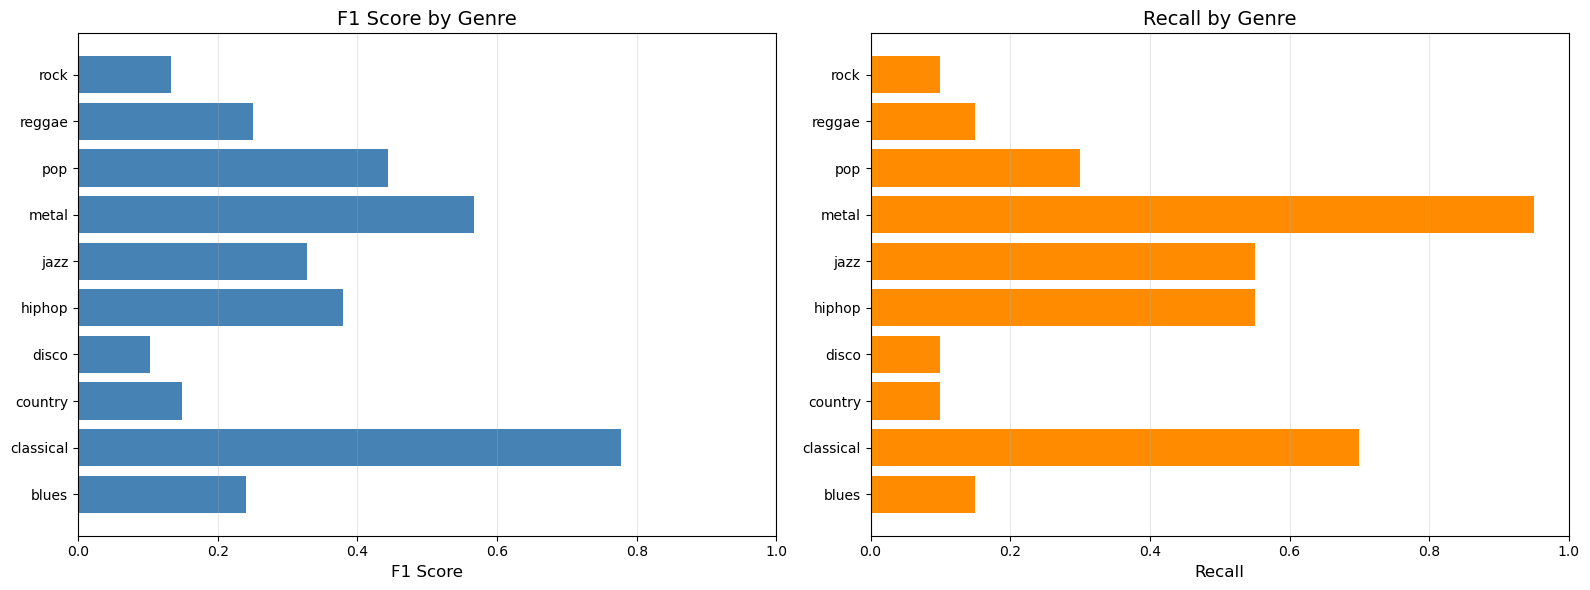

In [ ]:
# Get detailed performance metrics by genre
report = classification_report(y_test, y_pred_labels, output_dict=True)

# Convert to DataFrame for better visualization
df_report = pd.DataFrame(report).transpose()

# Display genre-level metrics
print("="*70)
print("PER-GENRE PERFORMANCE METRICS")
print("="*70)
print(df_report.head(len(genres)))

# Extract F1 and recall (per-genre accuracy)
f1_scores = [report[genre]['f1-score'] for genre in genres]
accuracy_by_genre = [report[genre]['recall'] for genre in genres]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot F1 scores
ax1.barh(genres, f1_scores, color='steelblue')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('F1 Score by Genre', fontsize=14)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Plot accuracy (recall) by genre
ax2.barh(genres, accuracy_by_genre, color='darkorange')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_title('Recall by Genre', fontsize=14)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Key Figures and Findings

In [ ]:
# defining function to compute the number of songs predicted across all genres for the positive genre

def plot_prediction_frequency(target_genre):

    rates = [] # will hold the rate of not target_genre for all songs that are the target_genre

    for g in genres_list: # looping through each genre
        subset = y_pred[y_test == g] # separating to get only songs of the true_genre
        rate = np.mean(subset == target_genre) # calculates the proportion predicted as target_genre
        rates.append(rate) # appends to list

    sns.barplot(x=genres_list, y=rates) # creates barplot to display rates by genre

    plt.xticks(rotation=45)
    plt.ylabel(f"Proportion Predicted as {target_genre.capitalize()}")
    plt.xlabel("True Genre")
    plt.title(f"Frequency of {target_genre.capitalize()} Predictions by True Genre")

    plt.show()

## Metal
- High recall, F1 score and precision higher than average
- Consistenlty classifies songs as metal
- But, classifying other songs as metal - leading to low precision 
    - Suggests metal is acting as a catch all for other genres
    - Metal is a tight cluster, as predictions are accurate, but preferred by the model (lots of false positives)

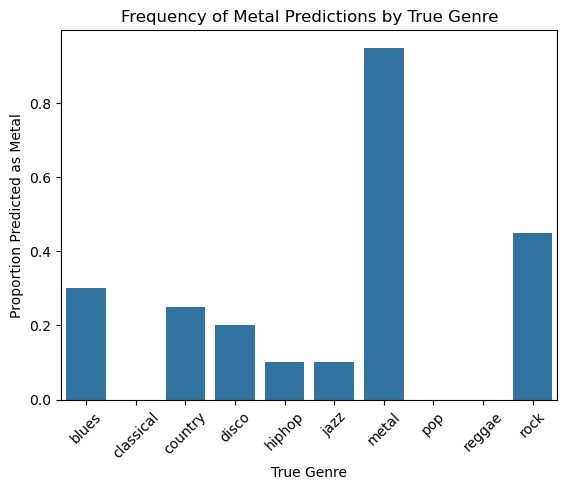

In [84]:
plot_prediction_frequency("metal")

## Jazz
- Average F1 score, with a higher than average accuracy but lower than average precision
- Suggests high number of false positives
- Supported with the figure + code below
    - See in the figure that across all genres, the proportion of times songs in those genres are predicted as jazz is large
    - The percentage of songs that aren't jazz being mis-classified as jazz = 20%
- Suggests the jazz cluster overlaps with other nearby clusters like country, blues, reggae, rock

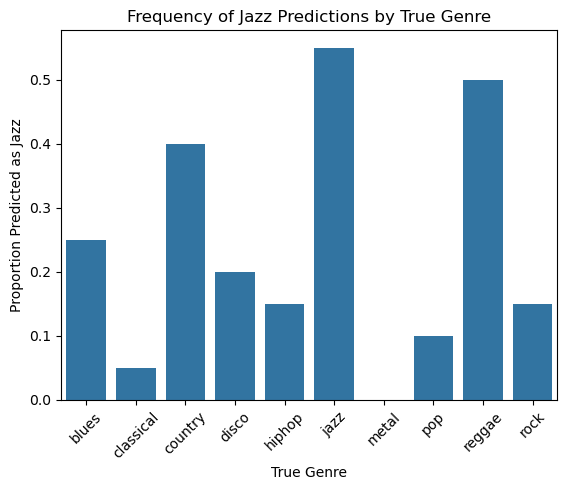

In [85]:
plot_prediction_frequency("jazz")

In [80]:
np.mean(y_pred[y_test != "jazz"] == "jazz")

np.float64(0.2)

## Classical
- Overall consistent, high recall, F1 score, and precision

## Country
- Low precision, recall, and F1 score
- Shows that the model struggles both in making predictions when a song is country, and distinguishing non-country songs from being country
- Suggests country doesn't form a strong cluster

## Blues
- Relatively high precision, but low recall and F1
- Looking at the figure below, see the stronger clusters are taking over
- The model is conservative in predicting blues
- Suggests that blues cluster could sit near jazz cluster, which explains the large number of jazz predictions
- Also supports earlier conclusion about metal, that this label dominates 

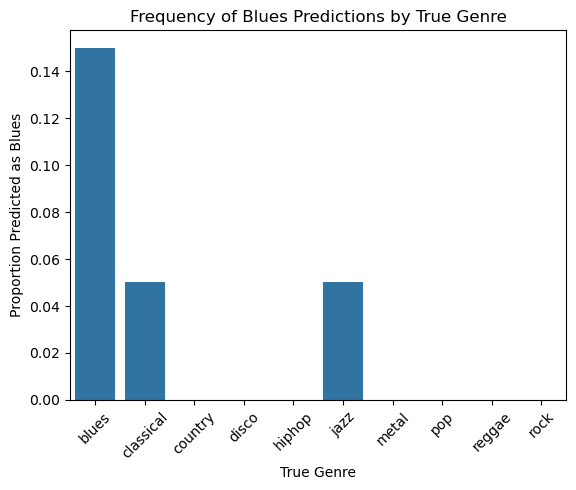

In [86]:
plot_prediction_frequency("blues")

## Pop & Reggae
- Have similar trend
- High precision but low recall and F1 score
- This means that the model doesn't often predict pop or reggae, but when it does this prediction is accurate
- Suggests these clusters are well-defined in the feature space, but other clusters dominate 
    - Could also be that the clusters are narrow/close to other clusters that are predicted more

## Disco & Hip Hop
- Seem to interact
- Disco has low precision, accuracy, and F1 score (worst performing genre)
- Out of disco songs, most of the predictions are hip hop
- Hip hop has high recall but low precision and F1 score
    - Seems to have a similar trend to jazz, but less extreme

## Rock
- Low F1, accuracy, and precision
- 45% of rock songs are classified as metal
- Hip hop and jazz also significant presence
- Suggests these other clusters dominate, leading to poor performance in this genre

# 10. Results Interpretation and Discussion

### Comparing the Models:
Compare the test set performance metrics between non-PCA and PCA models:
- **Accuracy**: Which model has higher overall accuracy?
- **F1 Score**: Which model better balances precision and recall?
- **Per-Genre Performance**: Are there specific genres that benefit more from PCA?

## Genre Classification Patterns
**Easier to Classify Genres** typically have:
- Distinctive audio features (e.g., metal has high energy and tempo; classical has distinct instrument timbres)
- Consistent patterns within the genre
- Clear separation from other genres in feature space

**Harder to Classify Genres** often have:
- Overlapping characteristics with other genres (e.g., rock and metal; pop and dance)
- High within-genre variability
- Fusion elements from multiple genres


# Analysis of Results

Based on the plots and metrics generated above, here are the key findings:

## Genre-Specific Insights

### Best Performing Genres:
From the F1 score bar charts in section 9, identify genres with F1 > 0.7:
- These genres likely have distinctive audio characteristics
- Clear separation in feature space from other genres
- Consistent patterns within the genre

### Worst Performing Genres:
Identify genres with F1 < 0.4:
- High overlap with similar genres
- Within-genre variability makes them hard to classify
- May benefit from additional features or different preprocessing